# **TELECOM X PARTE 2 - PREDICCIÓN DE CANCELACIÓN CHURN📉**

## **🛠️ Preparación de los Datos**

**Instalamos la biblioteca [pandas](https://pandas.pydata.org/) para realizar el análisis de datos**

In [65]:
%pip install -r /content/Requeriments.txt

**Asignacion de alias a librerías**

In [66]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

**Se importó pandas para realizar la extracción desde el archivo cargado en el entorno de trabajo, para el análisis y visualización de los datos. En conjunto de [IPython.display](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display) módulo con su función principal [display](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display).Permitiendo mostrar un objeto Python, determinando automáticamente la mejor representación para el objeto**

In [67]:
import pandas as pd
from IPython.display import display


try:
    #Cargamos los datos
    datos = '/content/Analisis_Telecom_X_Limpio_y_Transformado'
    df_telecomx = pd.read_csv(datos)

except Exception as e:
    # Archivo no cargado en el entorno de trabajo
    print(f'Error al extraer los datos: {e}')

else:
    # Usamos display() para ver el DataFrame formateado si no hay error
    pd.set_option('display.max_columns', None)
    display(df_telecomx.head())

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily_Total
0,0002-ORFBO,0,Female,0,1,1,9,DSL,0,1,0,1,1,0,1,0,One year,1,Mailed check,65.6,593.30,2.20
1,0003-MKNFE,0,Male,0,0,0,9,DSL,0,0,0,0,0,1,1,1,Month-to-month,0,Mailed check,59.9,542.40,2.01
2,0004-TLHLJ,1,Male,0,0,0,4,Fiber optic,0,0,1,0,0,0,1,0,Month-to-month,1,Electronic check,73.9,280.85,2.34
3,0011-IGKFF,1,Male,1,1,0,13,Fiber optic,0,1,1,0,1,1,1,0,Month-to-month,1,Electronic check,98.0,1237.85,3.17
4,0013-EXCHZ,1,Female,1,1,0,3,Fiber optic,0,0,0,1,1,0,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.97


**Eliminamos la columna CustomerID, ya que para los modelos de predicción esta columna no aporta valor o puede afectar al mismo**

In [68]:
try:
    #Realizamos la copia del DataFrame original
    df_telecomx_nuevo = df_telecomx.copy()

    #Eliminamos la columna innecesaria
    df_telecomx_nuevo = df_telecomx_nuevo.drop(columns='customerID')
except Exception as e:
    print(f'Error al eliminar la columna customerID: {e}')
else:
    #Mostramos el resultado
    display(df_telecomx_nuevo.head())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily_Total
0,0,Female,0,1,1,9,DSL,0,1,0,1,1,0,1,0,One year,1,Mailed check,65.6,593.30,2.20
1,0,Male,0,0,0,9,DSL,0,0,0,0,0,1,1,1,Month-to-month,0,Mailed check,59.9,542.40,2.01
2,1,Male,0,0,0,4,Fiber optic,0,0,1,0,0,0,1,0,Month-to-month,1,Electronic check,73.9,280.85,2.34
3,1,Male,1,1,0,13,Fiber optic,0,1,1,0,1,1,1,0,Month-to-month,1,Electronic check,98.0,1237.85,3.17
4,1,Female,1,1,0,3,Fiber optic,0,0,0,1,1,0,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.97


**Creamos columna Phone_Category: con la categoria para cada casó combinando los valores de las columnas: PhoneService y MultipleLines apartir de una condición, todo esto para evitar redundancia entre las variables**

In [69]:
try:
    # Definimos las condiciones
    conditions = [
        (df_telecomx_nuevo['PhoneService'] == 1) & (df_telecomx_nuevo['MultipleLines'] == 1),
        (df_telecomx_nuevo['PhoneService'] == 0) & (df_telecomx_nuevo['MultipleLines'] == 0)
        ]

    # categorias
    categorias = ['Multiple Lines', 'No Phone Service']

    # Realizamos la operación y asignamos el valor a la columna
    df_telecomx_nuevo['Phone_Category'] = np.select(conditions, categorias, default='One Line')

except Exception as e:
    print(f'Error al crear la columna Phone_Category: {e}')
else:
    # visualizamos el resultado
    display(df_telecomx_nuevo.head())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily_Total,Phone_Category
0,0,Female,0,1,1,9,DSL,0,1,0,1,1,0,1,0,One year,1,Mailed check,65.6,593.30,2.20,One Line
1,0,Male,0,0,0,9,DSL,0,0,0,0,0,1,1,1,Month-to-month,0,Mailed check,59.9,542.40,2.01,Multiple Lines
2,1,Male,0,0,0,4,Fiber optic,0,0,1,0,0,0,1,0,Month-to-month,1,Electronic check,73.9,280.85,2.34,One Line
3,1,Male,1,1,0,13,Fiber optic,0,1,1,0,1,1,1,0,Month-to-month,1,Electronic check,98.0,1237.85,3.17,One Line
4,1,Female,1,1,0,3,Fiber optic,0,0,0,1,1,0,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.97,One Line


**Realizamos la separación de las variables donde: X -> tendra las variables explicativas, y -> tendra la variable objetivo.**

In [70]:
try:
  #Separamos el conjunto de Datos en 2 partes:

  # y: alamcenara la variable objetivo o interés
  y = df_telecomx_nuevo['Churn']

  # X: almacenara las variables explicativas
  X = df_telecomx_nuevo.drop(columns='Churn')

except Exception as e:
  print(f'Error al tratar la variable objetivo: {e}')
else:
  print('Cambios realizados exitosamente')

Cambios realizados exitosamente


**Calculamos la proporción de clientes que cancelaron y los que permanecen activos. Evaluando si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.**

In [80]:
try:
  #Creamos variable que contiene la cantidad por tipo
  proporcion = y.value_counts()
except Exception as e:
  print(f'Error revisar la variable objetivo: {e}')
else:
  #Mostramos el resultado
  display(proporcion)


,count
Churn,
0,5376
1,1891


**Utilizamos los métodos [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html), [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) de la biblioteca de aprendizaje automático (Machine Learning) [Scikit-learn](https://scikit-learn.org/) para el tratamiento y estandarizacion de las variables de todo el conjunto, y ser utilizadas en los modelos de prediccion**

In [77]:
try:

  # Importamos las funciones
  from sklearn.compose import ColumnTransformer
  from sklearn.preprocessing import OneHotEncoder,StandardScaler

  # Creamos las variables con las columnas categóricas y numéricas
  categorical_features = ['InternetService', 'Contract', 'PaymentMethod', 'gender','Phone_Category']
  numeric_features = ['tenure', 'ChargesMonthly', 'ChargesTotal', 'ChargesDaily_Total']

  # Estructuramos la tranformacion y parametros para tratar las variables
  transformer = ColumnTransformer(transformers=[
  ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
  ('num', StandardScaler(), numeric_features)],
  remainder='passthrough' # Mantiene el resto de columnas si las hay
  )

  # Copiamos los datos de las variables explicativas para realizar la tranformacion en un objeto independiente
  X_transformer = X.copy()

  # Ajustar y transformar las variables explicativas
  X_procesado = transformer.fit_transform(X_transformer)

  # Creamos variable con los nombres de las columnas transformadas
  encoded_cols = transformer.get_feature_names_out(X_transformer.columns)

  # Creamos DataFrame con las datos transformados y estandarizados
  X_final = pd.DataFrame(X_procesado, columns=encoded_cols)

  # Eliminamos las columnas que causan el ruido matemático
  X_final = X_final.drop(columns=['num__ChargesDaily_Total', 'num__ChargesMonthly', 'num__ChargesTotal','remainder__MultipleLines','remainder__PhoneService'])

except Exception as e:
  print(f'Error al tratar las variables: {e}')
else:
  # Mostramos como quedo el resultado
  display(X_final.head())

,cat__InternetService_Fiber optic,cat__InternetService_No,cat__Contract_One year,cat__Contract_Two year,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,cat__gender_Male,cat__Phone_Category_No Phone Service,cat__Phone_Category_One Line,num__tenure,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingTV,remainder__StreamingMovies,remainder__PaperlessBilling
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.950200,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.950200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,-1.153700,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,-0.787401,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.194400,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0


## **🎯 Correlación y Selección de Variables**

**Calculamos el factor de inflación de la varianza para determinar la presencia de multicolinealidad o variables redundantes que son explicadas por otras ya que pueden afectar al modelo en su predicción debido a (overfitting o underfitting), en caso de que exista multicolinealidad tratar los datos para reducir esta**

In [74]:
try:
  # Importamos funcion para calcular la Multicolinealidad
  from statsmodels.stats.outliers_influence import variance_inflation_factor

  # Calcular VIF para cada variable explicativas

  # Creamos DataFrame
  vif_data = pd.DataFrame()

  # Columna que tendra los nombres de las columnas explicativas
  vif_data["variable"] = X_final.columns

  # Columna que tendra variance_inflation_factor
  vif_data["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(len(X_final.columns))]

except Exception as e:
  print(f'Error al calcular VIF: {e}')
else:
  # Visualizamos el resultado
  print(vif_data.sort_values(by="VIF", ascending=False))

                                      variable       VIF
3                       cat__Contract_Two year  3.218259
0             cat__InternetService_Fiber optic  2.875393
12                          remainder__Partner  2.727082
20                 remainder__PaperlessBilling  2.673528
10                                 num__tenure  2.588747
5          cat__PaymentMethod_Electronic check  2.528734
9                 cat__Phone_Category_One Line  2.482068
19                  remainder__StreamingMovies  2.441141
18                      remainder__StreamingTV  2.410808
1                      cat__InternetService_No  2.179443
6              cat__PaymentMethod_Mailed check  2.114556
16                 remainder__DeviceProtection  2.082167
13                       remainder__Dependents  1.968139
2                       cat__Contract_One year  1.949650
17                      remainder__TechSupport  1.920012
7                             cat__gender_Male  1.914938
15                     remainde

**Creamos gráfico para observar la correlación de cada variable con la variable objetivo "CHURN", la forma en la que podemos interpretar el resultado es la siguiente: mientras mas cerca este el valor de 1 índica mayor correlación, esto quiere decir que el aumento de la variable objetivo provoca el aumento de la variable en correlación a esta. En caso contrarió mientras más cerca de -1 este el valor menor correlación tiende a tener con la variable objetivo**

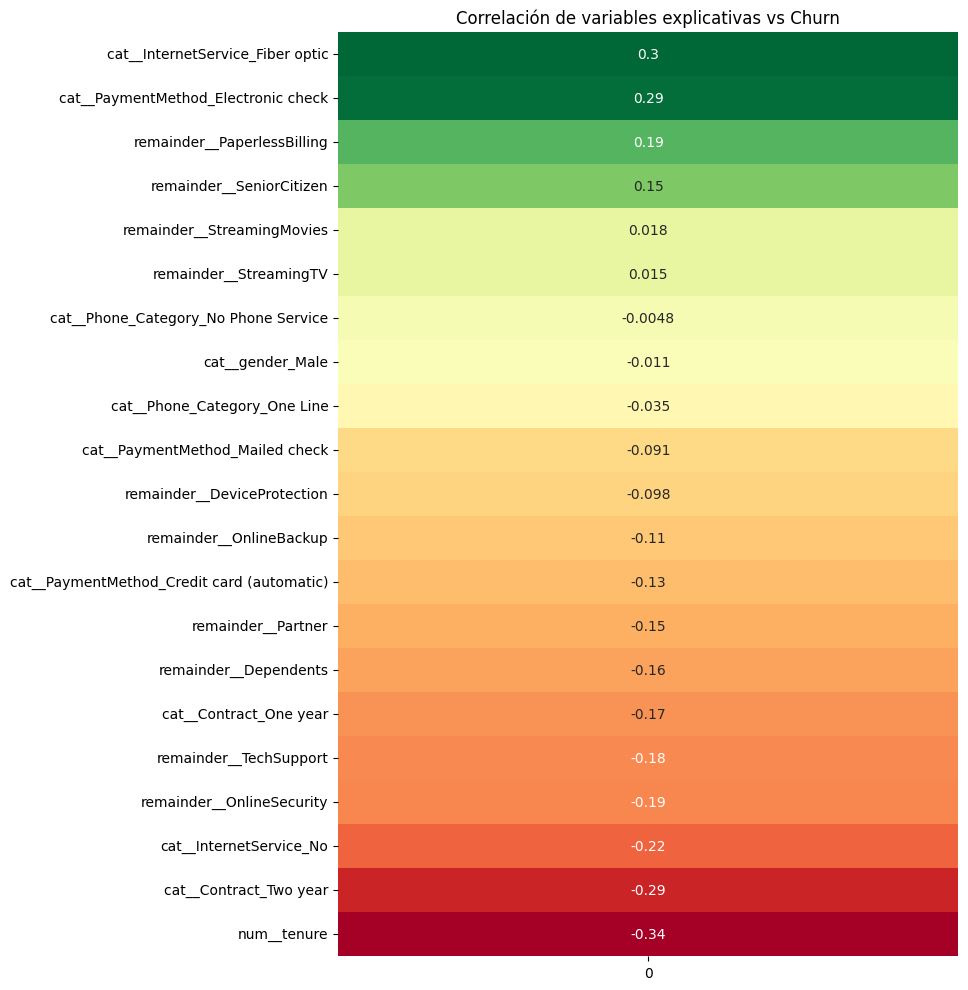

In [81]:
try:

  # Analizamos la correlacion de las variables explicativas con la variable objetivo
  corr_final = X_final.corrwith(y).sort_values(ascending=False)

  # Visualizamos el grafico con la correlacion
  plt.figure(figsize=(8, 12))
  sns.heatmap(corr_final.to_frame(), annot=True, cmap='RdYlGn', cbar=False)
  plt.title('Correlación de variables explicativas vs Churn')

except Exception as e:
  print(f'Error al realizar el análisis de correlación: {e}')
else:
  plt.show()